In [1]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
matplotlib.rcParams['pdf.fonttype'] = 42
import scipy.stats as st

import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils
large_data_dir = gf_utils.large_data_dir

matplotlib.rcParams['pdf.fonttype'] = 42


In [2]:
mrvi_adata = sc.read_h5ad(large_data_dir + 'MPN_WTA/mrvi_jak2_heterozygous_included.h5ad')


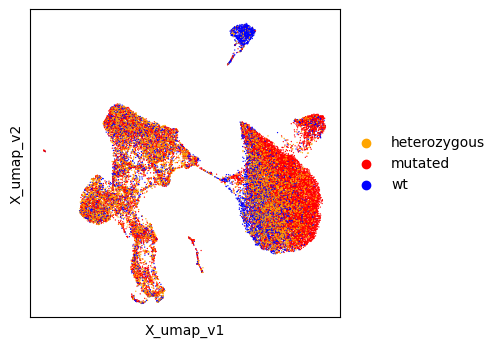

In [3]:
fig,ax = plt.subplots(figsize=(4,4))
sc.pl.embedding(mrvi_adata, color = 'genotype', basis='X_umap_v', ax=ax, show=False, title='', palette = {'mutated':'red','heterozygous':'orange','wt':'blue'})

# Get current axes and rasterize scatter points
ax = plt.gca()
for coll in ax.collections:
    coll.set_rasterized(True)

plt.savefig('../plots/mrvi_with_heterozygous_v_genotype.pdf', dpi=300, bbox_inches='tight')

In [4]:
len(mrvi_adata)

34343

/tmp/ipykernel_776346/2632490320.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([wt_list, het_list, mutated_list],


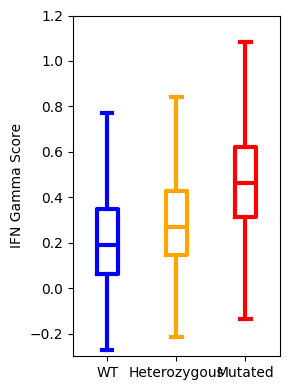

In [5]:
gene_set = pd.read_csv('../data/HALLMARK_INTERFERON_GAMMA_RESPONSE.v2025.1.Hs.tsv', sep='\t',index_col=0).loc['GENE_SYMBOLS'].values[0].split(',')
genes_present = []
for gene_name in gene_set:
    if gene_name in mrvi_adata.var_names:
        genes_present.append(gene_name)
geneset_id = [mrvi_adata.var_names.get_loc(j) for j in genes_present]

mrvi_adata.obs['ifn_gamma_score'] = np.mean(mrvi_adata.layers['zs_norm_log'][:, geneset_id], axis = 1)

wt_list = mrvi_adata[mrvi_adata.obs['cell_type'].isin(['Classical monocyte (non-HSPC)','Non-classical monocyte (non-HSPC)']) & (mrvi_adata.obs['genotype'] == 'wt')].obs['ifn_gamma_score']
het_list = mrvi_adata[mrvi_adata.obs['cell_type'].isin(['Classical monocyte (non-HSPC)','Non-classical monocyte (non-HSPC)']) & (mrvi_adata.obs['genotype'] == 'heterozygous')].obs['ifn_gamma_score']
mutated_list = mrvi_adata[mrvi_adata.obs['cell_type'].isin(['Classical monocyte (non-HSPC)','Non-classical monocyte (non-HSPC)']) & (mrvi_adata.obs['genotype'] == 'mutated')].obs['ifn_gamma_score']

fig, ax = plt.subplots(figsize=(3, 4))

# Create boxplots
bp = ax.boxplot([wt_list, het_list, mutated_list], 
                labels=['WT', 'Heterozygous', 'Mutated'],
                patch_artist=False)

# Set colors for the boxplot outlines
colors = ['blue', 'orange', 'red']
for i, (box, color) in enumerate(zip(bp['boxes'], colors)):
    box.set_color(color)
    bp['whiskers'][i*2].set_color(color)
    bp['whiskers'][i*2+1].set_color(color)
    bp['caps'][i*2].set_color(color)
    bp['caps'][i*2+1].set_color(color)
    bp['medians'][i].set_color(color)
    # Increase the linewidth of all boxplot elements
    for element in ['boxes', 'whiskers', 'caps', 'medians']:
        for line in bp[element]:
            line.set_linewidth(3)
# Remove outliers by setting showfliers to False
for patch in bp['fliers']:
    patch.set_visible(False)
ax.set_ylabel('IFN Gamma Score')

ax.set_ylim(-0.3, 1.2)
plt.tight_layout()

plt.savefig('../plots/mrvi_with_heterozygous_IFN_gamma_score.pdf', dpi=300, bbox_inches='tight')

In [6]:
len(wt_list), len(het_list), len(mutated_list)

(3320, 3505, 11280)

In [7]:
st.mannwhitneyu(wt_list, het_list, alternative='less'), st.mannwhitneyu(het_list, mutated_list, alternative='less'), st.mannwhitneyu(wt_list, mutated_list, alternative='less')

(MannwhitneyuResult(statistic=4551736.0, pvalue=6.04378438518374e-55),
 MannwhitneyuResult(statistic=11628371.0, pvalue=4.9721625715938744e-298),
 MannwhitneyuResult(statistic=8009589.5, pvalue=0.0))